In [1]:
print("Model Assemble")

Model Assemble


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv("CreditV1.csv")

df.head()

,Age_Group,Employment_Type,Employment_Stability,Income,Income_Variation,Income_Decrease_6M,Expenses,Monthly_Saving_Habit,Leisure_Spend_Percent,Savings_Months_Cover,...,Discipline_Score,Missed_30Days_Flag,Txn_Score,Behavioral_Risk_Score,Shock_Flag,EMI_Flag,Balance_Multiplier,Risk_raw,Risk_norm,Loan_Label
0,18-25,Unemployed,0,3579,"No, fixed",Slight decrease,2928,Sometimes,<10%,1-2 months,...,7.0,0.0,2,2.0,0.0,0,0.4,0.0,0.333333,3124.8
1,26-35,Salaried,0,61705,"No, fixed",No,29389,"Yes, consistently",<10%,6+ months,...,9.0,0.0,3,0.0,0.0,1,1.0,NaN,0.000000,19389.6
2,26-35,Student,0,35488,Slight variation,No,25110,Sometimes,25-40%,6+ months,...,8.0,0.0,2,1.0,0.0,1,0.8,NaN,0.166667,6226.8
3,36-45,Salaried,2,142180,Slight variation,No,53867,"Yes, consistently",<10%,3-6 months,...,9.0,0.0,2,0.0,0.0,0,0.8,0.0,0.000000,200000.0
4,36-45,Salaried,0,169387,Slight variation,No,106217,"Yes, consistently",<10%,6+ months,...,9.0,0.0,1,0.0,0.0,0,1.0,0.0,0.000000,200000.0


In [4]:
print("Shape:", df.shape)
print("\nMissing Values:\n")
print(df.isnull().sum())

Shape: (20000, 34)

Missing Values:

Age_Group                   0
Employment_Type             0
Employment_Stability        0
Income                      0
Income_Variation            0
Income_Decrease_6M          0
Expenses                    0
Monthly_Saving_Habit        0
Leisure_Spend_Percent       0
Savings_Months_Cover        0
Neg_Balance_Freq            0
Daily_Txn_Count             0
Shock_Last12M               0
Has_EMI                     0
EMI_Missed_Freq             0
Rent_Status                 0
Utility_Status              0
Insurance_Status            0
Missed_30Days               0
Surplus                     0
Expense_Ratio               0
Rent_Score                  0
Utility_Score               0
Insurance_Score             0
Discipline_Score            0
Missed_30Days_Flag          0
Txn_Score                   0
Behavioral_Risk_Score       0
Shock_Flag                  0
EMI_Flag                    0
Balance_Multiplier          0
Risk_raw                 8467
Ris

In [5]:
df['Risk_norm'].unique()

array([0.33333333, 0.        , 0.16666667, 0.5       , 0.66666667,
       0.83333333, 1.        ])

In [6]:
df = df.dropna(subset=["Loan_Label"])

In [7]:
X = df[[
    "Surplus",
    "Txn_Score",
    "Rent_Score",
    "Utility_Score",
    "Insurance_Score",
    "Missed_30Days_Flag",
    "Shock_Flag",
    "EMI_Flag",
    "Balance_Multiplier",
    "Employment_Stability",
    "Risk_norm"
]]

y = df["Loan_Label"]

In [8]:
print(df["Loan_Label"].isnull().sum())

0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

Training Size: (16000, 11)
Testing Size: (4000, 11)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
print(df['Loan_Label'].iloc[10] * 2)
# df['Employment_Stability']

19861.2


In [12]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

Linear Regression
RMSE: 62561.09885363461
R2: 0.50313900590251


In [13]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest
RMSE: 51566.481006012
R2: 0.6624320875035907


In [14]:
print(type(X_train))
print(X_train.dtypes)

<class 'pandas.core.frame.DataFrame'>
Surplus                   int64
Txn_Score                 int64
Rent_Score              float64
Utility_Score             int64
Insurance_Score         float64
Missed_30Days_Flag      float64
Shock_Flag              float64
EMI_Flag                  int64
Balance_Multiplier      float64
Employment_Stability      int64
Risk_norm               float64
dtype: object


In [15]:
Z = df[[
    "Surplus",
    "Txn_Score",
    "Rent_Score",
    "Utility_Score",
    "Insurance_Score",
    "Missed_30Days_Flag",
    "Shock_Flag",
    "EMI_Flag",
    "Balance_Multiplier",
    "Employment_Stability",
    "Risk_norm"
]].copy()

In [16]:
Z_train, Z_test, y_train, y_test = train_test_split(
    Z, y, test_size=0.2, random_state=42
)

In [17]:
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(Z_train, y_train)

xgb_pred = xgb.predict(Z_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

XGBoost
RMSE: 51889.18975052788
R2: 0.6581937923072942


In [18]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse],
    "R2 Score": [lr_r2, rf_r2, xgb_r2]
})

results.sort_values(by="R2 Score", ascending=False)

,Model,RMSE,R2 Score
1,Random Forest,51566.481006,0.662432
2,XGBoost,51889.189751,0.658194
0,Linear Regression,62561.098854,0.503139


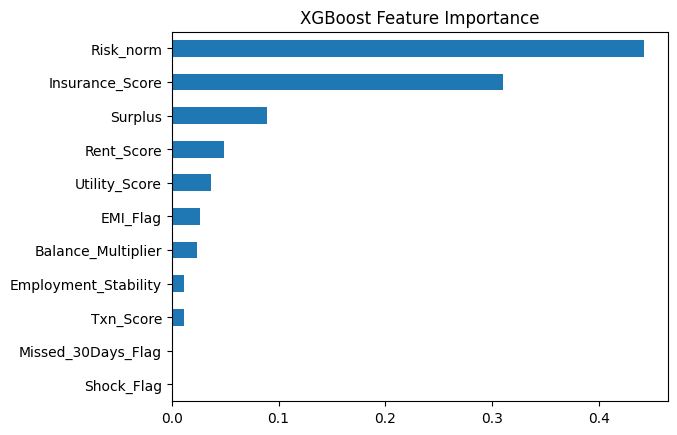

In [19]:
importances = pd.Series(xgb.feature_importances_, index=X.columns)

plt.figure()
importances.sort_values().plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.show()

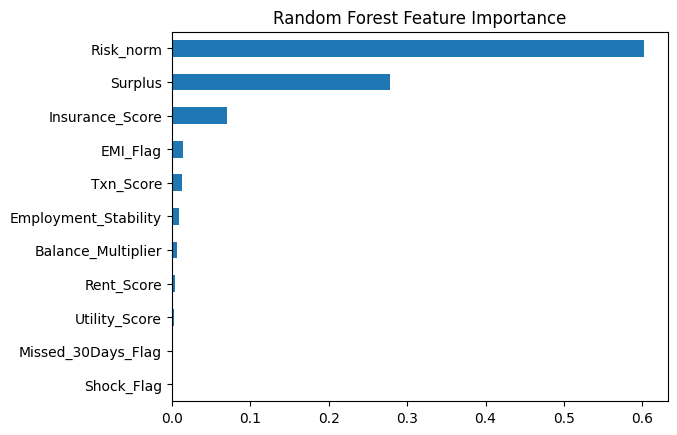

In [20]:
importances = pd.Series(rf.feature_importances_, index=X.columns)

plt.figure()
importances.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

In [21]:
# X = df[[
#     "Surplus",
#     "Txn_Score",
#     "Rent_Score",
#     "Utility_Score",
#     "Insurance_Score",
#     "Missed_30Days_Flag",
#     "Shock_Flag",
#     "EMI_Flag",
#     "Balance_Multiplier",
#     "Employment_Stability",
#     "Balance_Multiplier"
# ]]

# y = df["Loan_Label"]

In [22]:
new_user = {
    "Surplus": 40000,
    "Txn_Score": 3,
    "Rent_Score": 3,
    "Utility_Score": 3,
    "Insurance_Score": 3,
    "Missed_30Days_Flag": 0,
    "Shock_Flag": 0,
    "EMI_Flag": 1,
    "Balance_Multiplier": 0,
    "Employment_Stability": 4,
    "Risk_norm" :0.5
}

new_df = pd.DataFrame([new_user])

prediction = xgb.predict(new_df)

eligible_amount = np.clip(prediction[0], 0, 200000) - prediction[0]*0.1

print("Eligible Loan Amount: ₹", int(eligible_amount))
print("Lower Bound:", int(eligible_amount * 0.9))
print("Upper Bound:", int(eligible_amount * 1.1))

Eligible Loan Amount: ₹ 113370
Lower Bound: 102033
Upper Bound: 124707


In [23]:
import pandas as pd

importance = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                 Feature  Importance
10             Risk_norm    0.602362
0                Surplus    0.278430
4        Insurance_Score    0.070884
7               EMI_Flag    0.013794
1              Txn_Score    0.012477
9   Employment_Stability    0.008972
8     Balance_Multiplier    0.006346
2             Rent_Score    0.004239
3          Utility_Score    0.002496
6             Shock_Flag    0.000000
5     Missed_30Days_Flag    0.000000


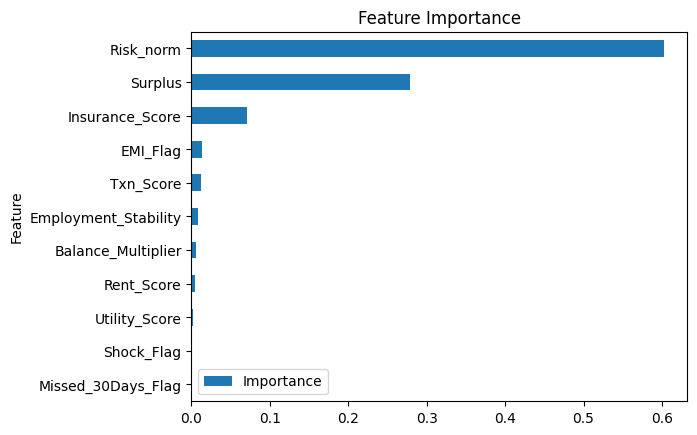

In [24]:
import matplotlib.pyplot as plt

feature_importance_df.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title("Feature Importance")
plt.show()

## Final XGBoost Pipeline and Model Export
This section trains an improved XGBoost regressor with hyperparameter search, evaluates performance, and saves the final model artifact as a `.pkl` file.

In [ ]:
import os
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# 1) Keep features explicit for stable training/inference
FEATURE_COLUMNS = [
    "Surplus",
    "Txn_Score",
    "Rent_Score",
    "Utility_Score",
    "Insurance_Score",
    "Missed_30Days_Flag",
    "Shock_Flag",
    "EMI_Flag",
    "Balance_Multiplier",
    "Employment_Stability",
    "Risk_norm",
]
TARGET_COLUMN = "Loan_Label"

# 2) Build clean modeling dataframe
model_df = df.dropna(subset=[TARGET_COLUMN]).copy()
X_all = model_df[FEATURE_COLUMNS].copy()
y_all = model_df[TARGET_COLUMN].astype(float)

# Ensure numeric coercion for safety
for col in FEATURE_COLUMNS:
    X_all[col] = pd.to_numeric(X_all[col], errors="coerce")

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# 3) Pipeline: imputation + XGBoost
pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "xgb",
            XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

# 4) Hyperparameter search (fast but meaningful range)
param_distributions = {
    "xgb__n_estimators": [250, 350, 500, 700],
    "xgb__max_depth": [3, 4, 5, 6, 8],
    "xgb__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "xgb__subsample": [0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "xgb__min_child_weight": [1, 3, 5, 7],
    "xgb__reg_alpha": [0.0, 0.01, 0.1, 1.0],
    "xgb__reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42,
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

# 5) Evaluate on holdout set
y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Params:")
print(search.best_params_)
print("\nFinal XGBoost Metrics (Holdout)")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

# 6) Refit on full dataset for final export
best_model.fit(X_all, y_all)

artifact = {
    "model": best_model,
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "best_params": search.best_params_,
    "metrics_holdout": {
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
    },
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "model_type": "xgboost_regressor_pipeline",
}

os.makedirs("artifacts", exist_ok=True)
model_output_path = os.path.join("artifacts", "xgboost_loan_model.pkl")
joblib.dump(artifact, model_output_path)

print(f"\nSaved: {model_output_path}")

Fitting 5 folds for each of 25 candidates, totalling 125 fits


In [4]:
# Quick validation: load saved artifact and run one prediction
saved_artifact = joblib.load(model_output_path)
loaded_model = saved_artifact["model"]
feature_cols = saved_artifact["feature_columns"]

sample_applicant = {
    "Surplus": 40000,
    "Txn_Score": 3,
    "Rent_Score": 3,
    "Utility_Score": 3,
    "Insurance_Score": 3,
    "Missed_30Days_Flag": 0,
    "Shock_Flag": 0,
    "EMI_Flag": 1,
    "Balance_Multiplier": 0,
    "Employment_Stability": 4,
    "Risk_norm": 0.5,
}

sample_df = pd.DataFrame([sample_applicant])[feature_cols]
predicted_amount = float(loaded_model.predict(sample_df)[0])

print("Loaded artifact prediction:", round(predicted_amount, 2))

Loaded artifact prediction: 144578.98
